# 05 · Delivery Performance, Sellers & Statistical Testing

**Business questions:** *How reliable is delivery? How much does lateness hurt satisfaction and retention? Which sellers cause problems?*

**New skills today**
- **Hypothesis testing**: t-test, Mann-Whitney, chi-square, correlation, and what a **p-value** actually means
- **Statistical vs practical significance** (effect size)
- Building a **seller scorecard** with business rules

In [1]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append("../src")
from chart_style import apply_style, save, COLORS
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "olist.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()

# delivered orders with a delivery date, inside the analysis window
con.execute("""
    CREATE OR REPLACE TEMP VIEW delivered AS
    SELECT * FROM marts.fct_orders
    WHERE in_analysis_window AND order_status = 'delivered' AND delivered_at IS NOT NULL
""");

## 1. Delivery KPIs

In [2]:
sql("""
    SELECT COUNT(*)                                  AS delivered_orders,
           ROUND(AVG(delivery_days), 1)              AS avg_delivery_days,
           MEDIAN(delivery_days)                     AS median_delivery_days,
           ROUND(100 * AVG(CAST(is_late AS INT)), 1) AS late_pct,
           ROUND(AVG(days_vs_estimate), 1)           AS avg_days_vs_estimate
    FROM delivered
""")

,delivered_orders,avg_delivery_days,median_delivery_days,late_pct,avg_days_vs_estimate
0,96203,12.5,10.0,6.8,-11.8


**Findings**
- Orders take **~12.5 days** on average (median 10) to arrive, and **6.8% arrive late**.
- On average, orders arrive **~12 days *before* the estimated date**. Olist's estimates are very padded.
  That protects the late rate, but a "3-week" estimate at checkout may scare customers away. → Opportunity: tighter, more accurate estimates.

## 2. Where does the time go?
An order passes through three stages. Measuring each one tells us **who** to fix: Olist (approval), the **seller** (packing & handing over), or the **carrier** (last mile).

,approval_days,seller_handling_days,carrier_days
0,0.4,2.8,9.4


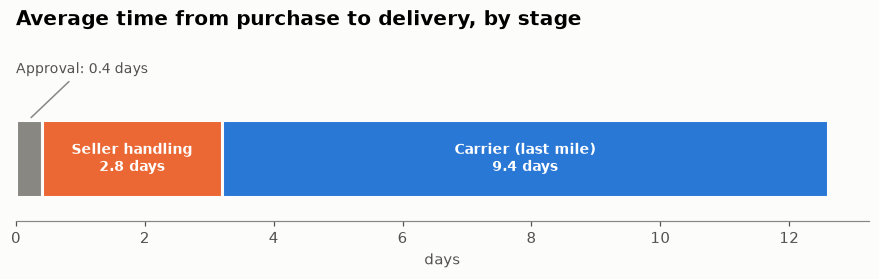

In [3]:
stages = sql("""
    SELECT ROUND(AVG(date_diff('hour', purchased_at, approved_at)) / 24, 1) AS approval_days,
           ROUND(AVG(date_diff('hour', approved_at,  shipped_at))  / 24, 1) AS seller_handling_days,
           ROUND(AVG(date_diff('hour', shipped_at,   delivered_at)) / 24, 1) AS carrier_days
    FROM delivered
    WHERE shipped_at >= approved_at           -- skip a few rows with impossible timestamps
""")
display(stages)

vals = stages.iloc[0]
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.set_ylim(-0.4, 0.8)
left = 0
for label, v, col in zip(["Approval", "Seller handling", "Carrier (last mile)"], vals, [COLORS["grey"], COLORS["orange"], COLORS["blue"]]):
    ax.barh(0, v, left=left, color=col, height=0.5, edgecolor="#fcfcfb", linewidth=2)
    if v >= 1:   # label inside the bar only if the segment is wide enough
        ax.text(left + v / 2, 0, f"{label}\n{v} days", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    else:        # tiny segment: label above it instead
        ax.annotate(f"{label}: {v} days", xy=(left + v / 2, 0.25), xytext=(left, 0.55),
                    fontsize=9, color="#52514e", arrowprops=dict(arrowstyle="-", color="#898781"))
    left += v
ax.set_yticks([]); ax.grid(False); ax.spines["left"].set_visible(False)
ax.set_xlabel("days")
ax.set_title("Average time from purchase to delivery, by stage")
save(fig, "11_delivery_stages")
plt.show()

**Finding:** the **carrier leg takes ~75% of the total time** (~9.4 of ~12.6 days). Seller handling is ~2.8 days.
→ The biggest lever is logistics partners and routes, not sellers (though a few slow sellers matter; see section 6).

## 3. When and where are deliveries late?

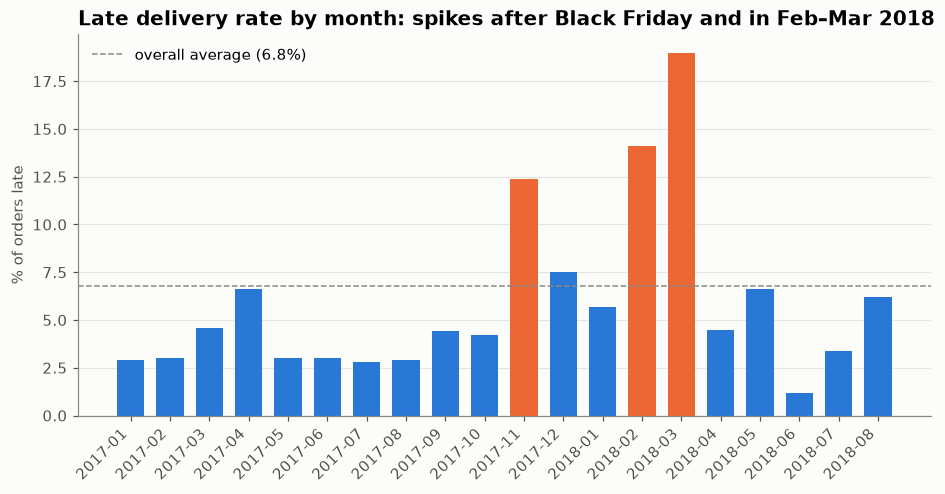

In [4]:
monthly = sql("""
    SELECT strftime(order_date, '%Y-%m')              AS month,
           COUNT(*)                                   AS orders,
           ROUND(100 * AVG(CAST(is_late AS INT)), 1)  AS late_pct
    FROM delivered
    GROUP BY month ORDER BY month
""")
fig, ax = plt.subplots()
colors = [COLORS["orange"] if v > 10 else COLORS["blue"] for v in monthly["late_pct"]]
ax.bar(monthly["month"], monthly["late_pct"], color=colors, width=0.7)
ax.axhline(6.8, color=COLORS["grey"], linestyle="--", linewidth=1, label="overall average (6.8%)")
ax.set_ylabel("% of orders late")
ax.set_title("Late delivery rate by month: spikes after Black Friday and in Feb–Mar 2018")
ax.legend(loc="upper left")
plt.xticks(rotation=45, ha="right")
save(fig, "12_late_rate_by_month")
plt.show()

**Finding:** late deliveries **spike to 12% in Nov 2017** (Black Friday volume) and **14–19% in Feb–Mar 2018**, the months right after order volume jumped.
The logistics network didn't scale with demand. → Capacity planning before peaks.

In [5]:
by_state = sql("""
    SELECT customer_state                            AS state,
           COUNT(*)                                  AS orders,
           ROUND(AVG(delivery_days), 1)              AS avg_delivery_days,
           ROUND(100 * AVG(CAST(is_late AS INT)), 1) AS late_pct
    FROM delivered
    GROUP BY state
    HAVING COUNT(*) >= 300          -- skip states with too few orders for a reliable rate
    ORDER BY late_pct DESC
""")
by_state.head(10)

,state,orders,avg_delivery_days,late_pct
0,AL,396,24.5,21.5
1,MA,713,21.5,17.5
2,SE,332,21.4,15.4
3,PI,475,19.4,13.9
4,CE,1273,21.2,13.8
5,BA,3253,19.3,12.2
6,RJ,12310,15.2,12.1
7,PA,942,23.7,11.3
8,ES,1992,15.7,10.7
9,PB,516,20.4,10.5


**Finding:** North-East states (AL, MA, SE, PI, CE, BA) have **2–3× the average late rate** and take ~20+ days.
Notably **Rio de Janeiro (RJ)**, the 2nd-biggest market, is late **12%** of the time vs ~6% in SP. That's a big, fixable problem given RJ's volume.

## 4. How much does lateness hurt reviews?
Bucket orders by how early or late they arrived compared to the estimate:

,arrival,orders,avg_review,pct_bad_reviews
0,1. 10+ days early,61270,4.32,8.9
1,2. 1-9 days early,26632,4.23,10.0
2,3. on the day,1280,4.03,12.4
3,4. 1-3 days late,1851,3.29,32.1
4,5. 4-7 days late,1748,2.10,67.7
5,6. 8+ days late,2779,1.70,79.3


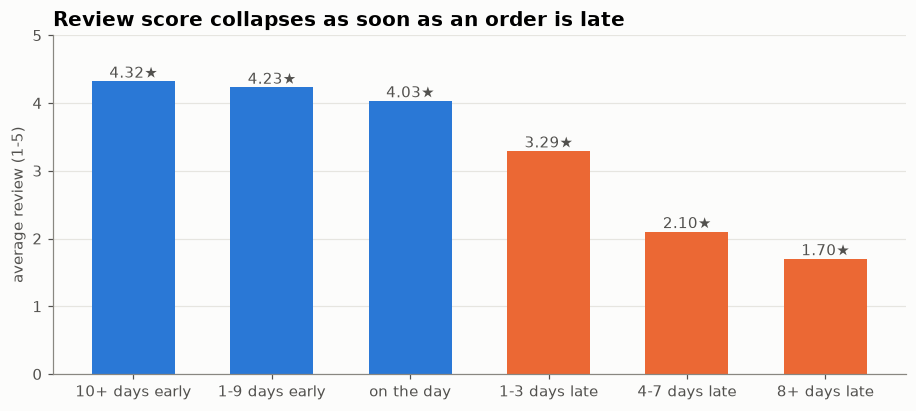

In [6]:
buckets = sql("""
    SELECT CASE
             WHEN days_vs_estimate <= -10 THEN '1. 10+ days early'
             WHEN days_vs_estimate <= -1  THEN '2. 1-9 days early'
             WHEN days_vs_estimate = 0    THEN '3. on the day'
             WHEN days_vs_estimate <= 3   THEN '4. 1-3 days late'
             WHEN days_vs_estimate <= 7   THEN '5. 4-7 days late'
             ELSE                              '6. 8+ days late'
           END                               AS arrival,
           COUNT(*)                          AS orders,
           ROUND(AVG(review_score), 2)       AS avg_review,
           ROUND(100 * AVG(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END), 1) AS pct_bad_reviews
    FROM delivered
    WHERE review_score IS NOT NULL
    GROUP BY arrival ORDER BY arrival
""")
display(buckets)

fig, ax = plt.subplots(figsize=(10, 4))
cols = [COLORS["blue"]] * 3 + [COLORS["orange"]] * 3
ax.bar(buckets["arrival"].str[3:], buckets["avg_review"], color=cols, width=0.6)
for x, v in enumerate(buckets["avg_review"]):
    ax.text(x, v, f"{v:.2f}★", ha="center", va="bottom", color="#52514e")
ax.set_ylim(0, 5)
ax.set_ylabel("average review (1-5)")
ax.set_title("Review score collapses as soon as an order is late")
save(fig, "13_review_by_lateness")
plt.show()

**Finding:** arriving early vs. on the estimated day barely matters (4.3 → 4.0), but **1–3 days late drops to 3.3★, and 4+ days late to ~2★**.
Among orders 8+ days late, most reviews are 1–2 stars. **Customers punish lateness, not slowness.**

## 5. Statistical testing: is it real or chance?
We keep saying "late orders get worse reviews". A skeptic asks: *could that difference be random luck?* Hypothesis testing answers that.

**The logic (memorise this):**
1. **Null hypothesis (H₀):** there is *no* real difference (e.g. late and on-time orders have the same average review).
2. Compute how likely our observed difference would be **if H₀ were true** → that probability is the **p-value**.
3. If **p < 0.05** (our chosen significance level α), the result would be very unlikely under H₀ → **reject H₀**: the difference is *statistically significant*.

⚠️ A p-value is **not** "the probability H₀ is true", and "significant" does **not** mean "big". With 90,000 rows even tiny differences are significant, so always report the **effect size** too.

### Test 1: Review score, late vs on-time (Welch's t-test)
A **t-test** compares the **means** of two groups. *Welch's* version doesn't assume both groups have the same spread (safer default).

In [7]:
reviews = sql("SELECT is_late, review_score FROM delivered WHERE review_score IS NOT NULL")
late    = reviews[reviews.is_late]["review_score"]
on_time = reviews[~reviews.is_late]["review_score"]

t_stat, p_value = stats.ttest_ind(late, on_time, equal_var=False)

# effect size: Cohen's d = difference in means / pooled standard deviation
pooled_sd = np.sqrt((late.var() + on_time.var()) / 2)
cohens_d = (on_time.mean() - late.mean()) / pooled_sd

print(f"On-time: mean {on_time.mean():.2f}  (n={len(on_time):,})")
print(f"Late:    mean {late.mean():.2f}  (n={len(late):,})")
print(f"Difference: {on_time.mean() - late.mean():.2f} stars")
print(f"t = {t_stat:.1f},  p-value = {p_value:.1e}")
print(f"Cohen's d = {cohens_d:.2f}   (rule of thumb: 0.2 small, 0.5 medium, 0.8+ large)")

On-time: mean 4.29  (n=89,182)
Late:    mean 2.27  (n=6,378)
Difference: 2.02 stars
t = -100.8,  p-value = 0.0e+00
Cohen's d = 1.47   (rule of thumb: 0.2 small, 0.5 medium, 0.8+ large)


**Result:** p is essentially 0 → reject H₀. And **Cohen's d ≈ 1.4, a very large effect**. It's both statistically *and* practically significant.

### Test 2: Same question, non-parametric (Mann-Whitney U)
Review scores are **ordinal** (1–5 stars, not truly continuous), so some statisticians prefer a test that compares **ranks** instead of means.
If both tests agree, our conclusion is robust.

In [8]:
u_stat, p_mw = stats.mannwhitneyu(late, on_time, alternative="two-sided")
print(f"Mann-Whitney U p-value = {p_mw:.1e}  → same conclusion")

Mann-Whitney U p-value = 0.0e+00  → same conclusion


### Test 3: Does a late first delivery reduce repeat purchases? (chi-square test)
On Day 4 we saw repeat rates of **2.5% (late first order) vs 3.1% (on time)**. Both variables are **categories** (late yes/no × repeat yes/no),
so we use a **chi-square test of independence** on the 2×2 table of counts.

In [9]:
first = sql("""
    SELECT o.is_late,
           c.total_orders > 1 AS repeated
    FROM delivered o
    JOIN marts.dim_customers c ON o.customer_unique_id = c.customer_unique_id
    WHERE o.customer_order_number = 1
""")
table = pd.crosstab(first["is_late"], first["repeated"])      # counts in a 2x2 grid
table.index = ["on time", "late"]; table.columns = ["did not return", "returned"]
display(table)

chi2, p_chi, dof, expected = stats.chi2_contingency(table)
rates = table["returned"] / table.sum(axis=1) * 100
print(f"Repeat rate: on time {rates['on time']:.2f}%  vs  late {rates['late']:.2f}%")
print(f"Relative drop: {100 * (1 - rates['late'] / rates['on time']):.0f}%")
print(f"chi-square = {chi2:.1f},  p-value = {p_chi:.4f}")

,did not return,returned
on time,83940,2699
late,6180,160


Repeat rate: on time 3.12%  vs  late 2.52%
Relative drop: 19%
chi-square = 6.7,  p-value = 0.0094


**Result:** p < 0.05 → the lower repeat rate after a late first delivery is **statistically significant**, not chance.
Late first deliveries cost repeat business (~19% relative drop).

⚠️ **Correlation ≠ causation.** Late orders may also differ in other ways (e.g. more from far-away states). The test shows a real *association*;
proving *cause* would need an experiment (A/B test), which is worth saying in an interview.

### Test 4: Correlation, delivery time vs review score
**Spearman correlation** (ρ, "rho") measures whether two variables move together, from −1 (perfectly opposite) to +1 (perfectly together). It uses ranks, so it suits ordinal reviews.

In [10]:
d = sql("SELECT delivery_days, days_vs_estimate, review_score FROM delivered WHERE review_score IS NOT NULL")
rho1, p1 = stats.spearmanr(d["delivery_days"], d["review_score"])
rho2, p2 = stats.spearmanr(d["days_vs_estimate"], d["review_score"])
print(f"delivery_days    vs review: rho = {rho1:.2f}  (p = {p1:.1e})")
print(f"days_vs_estimate vs review: rho = {rho2:.2f}  (p = {p2:.1e})")

delivery_days    vs review: rho = -0.23  (p = 0.0e+00)
days_vs_estimate vs review: rho = -0.18  (p = 0.0e+00)


**Result:** both correlations are negative (longer / later → worse review), and **lateness vs the estimate** is the stronger one.
It confirms section 4: **what matters is meeting the promise**, not raw speed.

## 6. Seller scorecard
Built in **`sql/marts/seller_scorecard.sql`**: one row per seller with orders, revenue, average review, late rate and handling time, plus a flag:
- **Low volume**: fewer than 30 orders (too few to judge fairly)
- **Underperforming**: late rate > 15% **or** average review < 3.5
- **Good**: everyone else

In [11]:
flags = sql("""
    SELECT performance_flag,
           COUNT(*)                                                AS sellers,
           ROUND(SUM(revenue))                                     AS revenue,
           ROUND(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 1) AS pct_revenue,
           ROUND(AVG(avg_review), 2)                               AS avg_review,
           ROUND(100 * AVG(late_rate), 1)                          AS avg_late_pct
    FROM marts.seller_scorecard
    GROUP BY performance_flag
    ORDER BY revenue DESC
""")
flags

,performance_flag,sellers,revenue,pct_revenue,avg_review,avg_late_pct
0,Good,583,11342167.0,72.3,4.17,5.7
1,Low volume,2396,3508727.0,22.4,4.04,7.1
2,Underperforming,50,832813.0,5.3,3.55,16.7


In [12]:
# revenue concentration: what share of revenue comes from the top 10% of sellers?
conc = sql("""
    SELECT NTILE(10) OVER (ORDER BY revenue DESC) AS decile, revenue
    FROM marts.seller_scorecard
""")
top10 = conc[conc.decile == 1].revenue.sum() / conc.revenue.sum() * 100
print(f"Top 10% of sellers generate {top10:.0f}% of revenue")

sql("""
    SELECT seller_id, seller_state, orders, ROUND(revenue) AS revenue, avg_review,
           ROUND(100 * late_rate, 1) AS late_pct, avg_handling_days
    FROM marts.seller_scorecard
    WHERE performance_flag = 'Underperforming'
    ORDER BY revenue DESC
    LIMIT 10
""")

Top 10% of sellers generate 67% of revenue


,seller_id,seller_state,orders,revenue,avg_review,late_pct,avg_handling_days
0,7c67e1448b00f6e969d365cea6b010ab,SP,982,239536.0,3.49,9.1,11.4
1,06a2c3af7b3aee5d69171b0e14f0ee87,MA,392,48550.0,3.99,19.0,4.5
2,712e6ed8aa4aa1fa65dab41fed5737e4,SC,79,46704.0,3.38,20.8,7.2
3,2eb70248d66e0e3ef83659f71b244378,SP,202,45860.0,2.70,11.2,10.8
4,88460e8ebdecbfecb5f9601833981930,PR,247,36377.0,3.42,17.1,7.4
5,710e3548e02bc1d2831dfc4f1b5b14d4,PR,134,27461.0,3.35,3.9,3.4
6,8444e55c1f13cd5c179851e5ca5ebd00,MG,95,23984.0,3.33,6.5,10.6
7,cd68562d3f44870c08922d380acae552,SP,124,20564.0,3.97,15.6,3.3
8,abe42c5d03695b4257b5c6cbf4e6784e,RJ,50,18158.0,3.92,16.3,1.7
9,6039e27294dc75811c0d8a39069f52c0,SP,64,16047.0,3.69,17.5,5.9


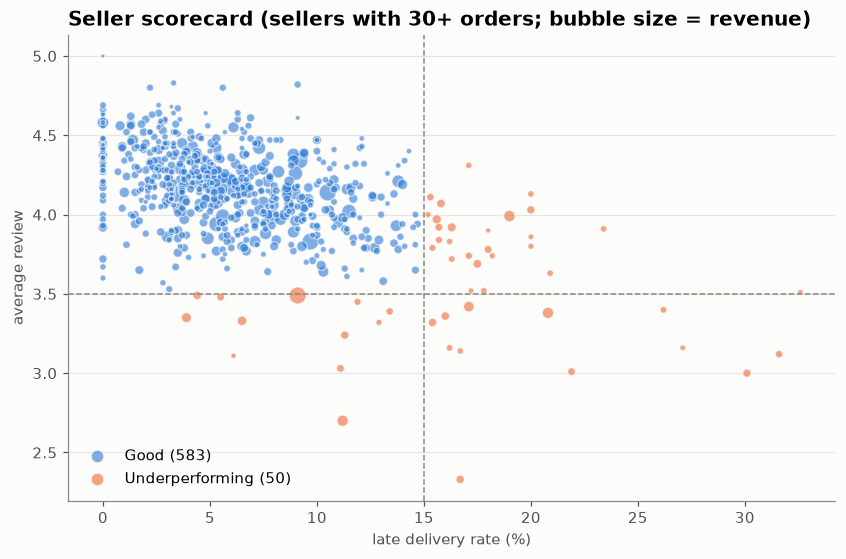

Seller handling time vs late rate: rho = 0.36 (p = 1.7e-20)


In [13]:
sc = sql("SELECT * FROM marts.seller_scorecard WHERE orders >= 30")
fig, ax = plt.subplots(figsize=(9, 5.5))
for flag, col in [("Good", COLORS["blue"]), ("Underperforming", COLORS["orange"])]:
    s = sc[sc.performance_flag == flag]
    ax.scatter(s["late_rate"] * 100, s["avg_review"], s=np.sqrt(s["revenue"]) / 4,
               color=col, alpha=0.6, edgecolor="#fcfcfb", linewidth=0.8, label=f"{flag} ({len(s)})")
ax.axvline(15, color=COLORS["grey"], linestyle="--", linewidth=1)
ax.axhline(3.5, color=COLORS["grey"], linestyle="--", linewidth=1)
ax.set_xlabel("late delivery rate (%)"); ax.set_ylabel("average review")
ax.set_title("Seller scorecard (sellers with 30+ orders; bubble size = revenue)")
ax.legend(loc="lower left")
save(fig, "14_seller_scorecard")
plt.show()

rho, p = stats.spearmanr(sc["avg_handling_days"], sc["late_rate"], nan_policy="omit")
print(f"Seller handling time vs late rate: rho = {rho:.2f} (p = {p:.1e})")

**Findings**
- Revenue is **highly concentrated**: the **top 10% of sellers bring ~2/3 of revenue**. Protecting and supporting them is critical.
- **50 established sellers are underperforming** (~5% of revenue), averaging 3.55★ and a **~17% late rate, about 3× that of good sellers**.
- ⚠️ One of them is the **#2 seller on the whole platform by revenue** (~R$ 240k). Fixing one big seller can matter more than 20 small ones.
- Sellers who take longer to hand orders to the carrier have **higher late rates** (positive correlation), so **handling time is a useful early-warning KPI**.
→ Put underperformers on an improvement plan (handling-time SLA, e.g. ship within 2 days), and deprioritise them in search if they don't improve.

---
## ✏️ Your turn
Answers in `LEARNING_NOTES.md`.
1. Late rate and average review by `main_payment_type`. Does boleto (which needs time to clear) show longer delivery?
2. **t-test practice:** is the average `order_revenue` different for late vs on-time orders? Report the p-value and the difference in means.
3. From `marts.seller_scorecard`: which **seller state** has the most `'Underperforming'` sellers?

In [ ]:
# 1. late rate and review by payment type

In [ ]:
# 2. t-test: order_revenue late vs on time

In [ ]:
# 3. underperforming sellers by state

---
## Summary: key findings (Delivery & Sellers)
| # | Finding | Evidence | So what? |
|---|---|---|---|
| 1 | 6.8% of orders are late; average delivery 12.5 days | KPIs | Baseline to improve |
| 2 | Orders arrive ~12 days **before** the estimate | days vs estimate | Estimates are over-padded; tighten them to improve conversion |
| 3 | The **carrier leg is ~75%** of delivery time | stage breakdown | Logistics partners are the main lever |
| 4 | Late rate **spiked to 12–19%** after Black Friday and in Feb–Mar 2018 | monthly trend | Plan capacity ahead of demand peaks |
| 5 | North-East states and **RJ (12% late)** perform worst | by state | Targeted carrier/route fixes |
| 6 | **Late orders: 2.3★ vs 4.3★** on time | t-test p≈0, Cohen's d≈1.4 (large) | Lateness is the #1 driver of bad reviews |
| 7 | **Late first delivery → ~19% lower repeat rate** | chi-square p<0.05 | Late deliveries also cost future revenue |
| 8 | Top 10% of sellers = ~2/3 of revenue; 50 established sellers underperform | seller scorecard | Seller SLAs + support for top sellers |

Next (Day 6): an interactive **Streamlit dashboard** bringing all of this together, deployed online with a public link.

In [ ]:
con.close()